# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_accuracy, memory_gb, status, description)
df = pd.read_csv("results_tiny_imagenet.tsv", sep="\t")
df["val_accuracy"] = pd.to_numeric(df["val_accuracy"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 52
Columns: ['commit', 'val_accuracy', 'memory_gb', 'status', 'description']


,commit,val_accuracy,memory_gb,status,description
0,af00df6,0.2866,6.5,KEEP,"label smoothing 0.05 (slight improvement, but ..."
1,ef57851,0.2819,6.5,KEEP,EMA weights (decay=0.995) - small improvement ...
2,dce4d60,0.2782,6.5,KEEP,"baseline re-run (depth=8, batch=128, MATRIX_LR..."
3,715140f,0.2741,6.5,DISCARD,ViT with EMA (no improvement over non-EMA base...
4,ae55c94,0.2176,6.5,DISCARD,data augmentation + label smoothing (hurts per...
5,05c9a42,0.1360,4.5,DISCARD,"depth=12 + batch=64 (too deep for budget, seve..."
6,05c9a42,0.1575,4.5,DISCARD,depth=12 + cosine LR (cosine doesn't fix under...
7,481748c,0.1771,6.5,KEEP,baseline ViT depth=4
8,7c62f67,0.1592,31.7,DISCARD,"increase aspect ratio 96->128 (wider model, wo..."
9,9220cec,0.1769,8.7,DISCARD,"depth=4 wider (aspect_ratio=128, same accuracy..."


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
KEEP       28
DISCARD    24

Keep rate: 28/52 = 53.8%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    acc = row["val_accuracy"] * 100
    desc = row["description"]
    print(f"  #{i:3d}  bpb={acc:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (28 total):

  #  0  bpb=28.660000  mem=6.5GB  label smoothing 0.05 (slight improvement, but not best)
  #  1  bpb=28.190000  mem=6.5GB  EMA weights (decay=0.995) - small improvement (+0.37pp over baseline re-run)
  #  2  bpb=27.820000  mem=6.5GB  baseline re-run (depth=8, batch=128, MATRIX_LR=0.02)
  #  7  bpb=17.710000  mem=6.5GB  baseline ViT depth=4
  # 10  bpb=20.340000  mem=23.6GB  depth=8 + value embeddings on alternating layers (ResFormer)
  # 11  bpb=18.170000  mem=23.6GB  depth=8 no value embeddings (ablation: depth alone = +0.46pp, VE = +2.17pp)
  # 14  bpb=21.260000  mem=23.6GB  VE LR=0.6 separate param (slight improvement from refactoring)
  # 15  bpb=21.620000  mem=23.6GB  VE LR=1.2 (best so far! +1.28pp from baseline VE)
  # 18  bpb=27.180000  mem=23.6GB  MATRIX_LR=0.02 (HOLY SMOKES! +5.56pp! Muon needs lower LR)
  # 25  bpb=27.980000  mem=12.1GB  smaller batch (512) + more steps (1381) = +0.8pp! NEW BEST!
  # 26  bpb=28.110000  mem=6.3GB  tiny batch (25

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

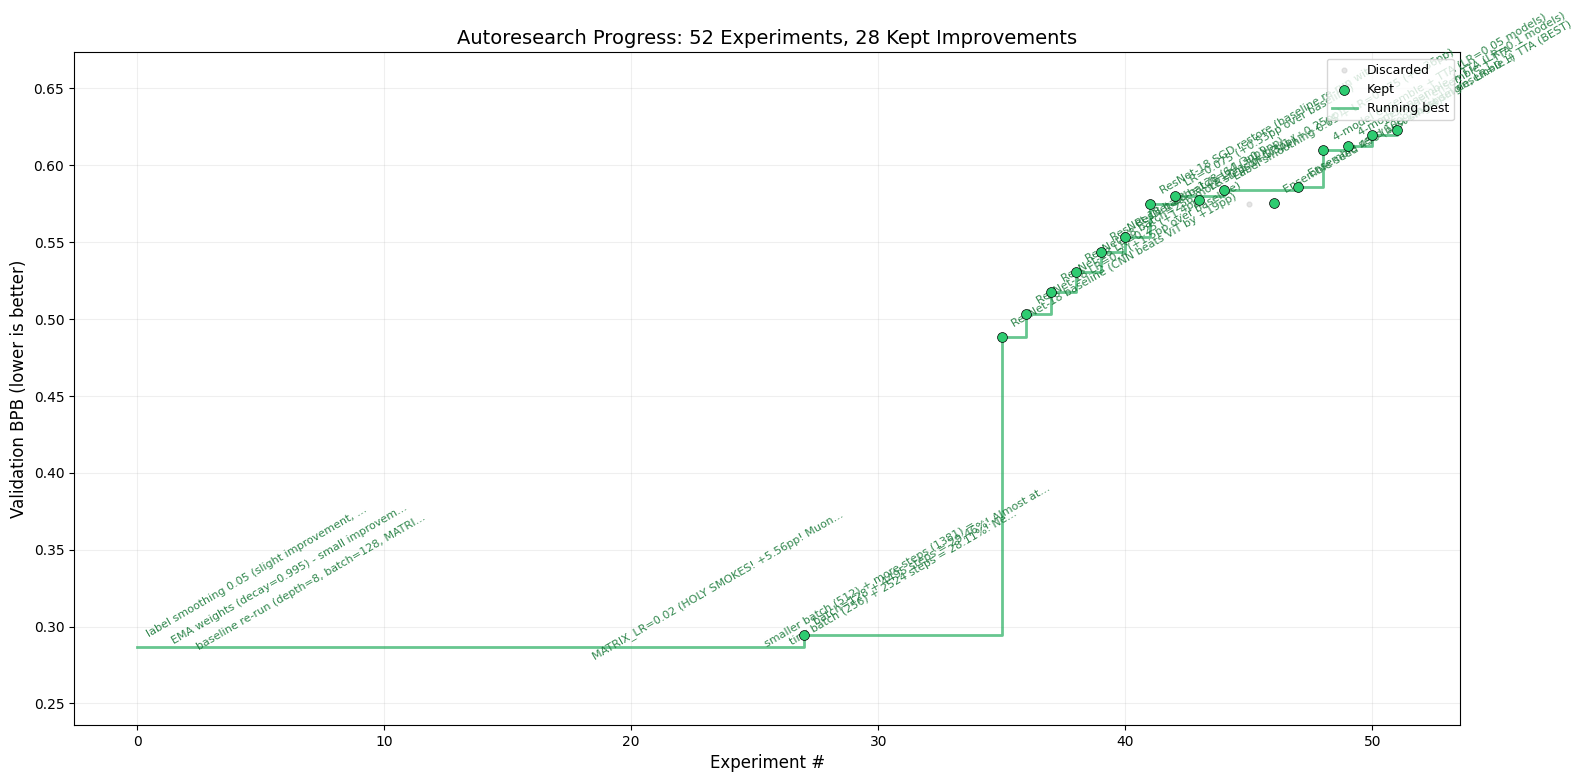

Saved to progress.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_acc = valid.loc[0, "val_accuracy"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_accuracy"] >= baseline_acc + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_accuracy"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_accuracy"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_accuracy"]
running_max = kept_bpb.cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

best = valid["val_accuracy"].max()

# Y-axis: from just below best to just above baseline
margin = (best - baseline_acc) * 0.15
ax.set_ylim(baseline_acc - margin, best + margin, )

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [ ]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

## Top Hits (Kept Experiments by Improvement)

In [ ]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")